Day 79 Param Sangani


# Setup and Context

### Introduction

On November 27, 1895, Alfred Nobel signed his last will in Paris. When it was opened after his death, the will caused a lot of controversy, as Nobel had left much of his wealth for the establishment of a prize.

Alfred Nobel dictates that his entire remaining estate should be used to endow “prizes to those who, during the preceding year, have conferred the greatest benefit to humankind”.

Every year the Nobel Prize is given to scientists and scholars in the categories chemistry, literature, physics, physiology or medicine, economics, and peace.

<img src=https://i.imgur.com/36pCx5Q.jpg>

Let's see what patterns we can find in the data of the past Nobel laureates. What can we learn about the Nobel prize and our world more generally?

### Upgrade plotly (only Google Colab Notebook)

Google Colab may not be running the latest version of plotly. If you're working in Google Colab, uncomment the line below, run the cell, and restart your notebook server.

In [1]:
%pip install --upgrade plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 45.8 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


### Import Statements

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

### Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

### Read the Data

In [4]:
df_data = pd.read_csv('nobel_prize_data.csv')

Caveats: The exact birth dates for Michael Houghton, Venkatraman Ramakrishnan, and Nadia Murad are unknown. I've substituted them with mid-year estimate of July 2nd.


# Data Exploration & Cleaning

**Challenge**: Preliminary data exploration.
* What is the shape of `df_data`? How many rows and columns?
* What are the column names?
* In which year was the Nobel prize first awarded?
* Which year is the latest year included in the dataset?

In [12]:
print(f"Shape of df_data: {df_data.shape}")
print(f"Column names: {df_data.columns.tolist()}")
print(f"First Nobel Prize awarded in: {df_data['year'].min()}")
print(f"Latest Nobel Prize included in dataset: {df_data['year'].max()}")

Shape of df_data: (962, 16)
Column names: ['year', 'category', 'prize', 'motivation', 'prize_share', 'laureate_type', 'full_name', 'birth_date', 'birth_city', 'birth_country', 'birth_country_current', 'sex', 'organization_name', 'organization_city', 'organization_country', 'ISO']
First Nobel Prize awarded in: 1901
Latest Nobel Prize included in dataset: 2020


### Check for Duplicates

Are there any duplicate values in the dataset?

Are there NaN values in the dataset?

Which columns tend to have NaN values?

How many NaN values are there per column?

Why do these columns have NaN values?

In [13]:
print(f"Number of duplicate rows: {df_data.duplicated().sum()}")
print("\nNumber of NaN values per column:")
print(df_data.isna().sum())

Number of duplicate rows: 0

Number of NaN values per column:
year                       0
category                   0
prize                      0
motivation                88
prize_share                0
laureate_type              0
full_name                  0
birth_date                28
birth_city                31
birth_country             28
birth_country_current     28
sex                       28
organization_name        255
organization_city        255
organization_country     254
ISO                       28
dtype: int64


### Type Conversions

**Challenge**:
* Convert the `birth_date` column to Pandas `Datetime` objects
* Add a Column called `share_pct` which has the laureates' share as a percentage in the form of a floating-point number.

#### Convert Year and Birth Date to Datetime

In [14]:
df_data['birth_date'] = pd.to_datetime(df_data['birth_date'])
df_data['year'] = pd.to_datetime(df_data['year'], format='%Y')


#### Add a Column with the Prize Share as a Percentage

In [16]:
split_shares = df_data['prize_share'].str.split('/', expand=True)
df_data['share_pct'] = split_shares[0].astype(float) / split_shares[1].astype(float)

print(df_data[['prize_share', 'share_pct']].head())

  prize_share  share_pct
0         1/1       1.00
1         1/1       1.00
2         1/1       1.00
3         1/2       0.50
4         1/2       0.50


# Plotly Donut Chart: Percentage of Male vs. Female Laureates

**Challenge**: Create a [donut chart using plotly](https://plotly.com/python/pie-charts/) which shows how many prizes went to men compared to how many prizes went to women. What percentage of all the prizes went to women?

In [ ]:
#what percentage of nobel prizes are given to scientists
#what is the average prize money given to the winners
#what percentage of awards are won solo

In [17]:
sex_counts = df_data['sex'].value_counts()

fig = px.pie(sex_counts,
             values=sex_counts.values,
             names=sex_counts.index,
             title='Nobel Prizes by Sex',
             hole=0.4) # Makes it a donut chart

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

female_percentage = (sex_counts['Female'] / sex_counts.sum()) * 100
print(f"\nPercentage of all prizes that went to women: {female_percentage:.2f}%")


Percentage of all prizes that went to women: 6.21%


# Who were the first 3 Women to Win the Nobel Prize?

**Challenge**:
* What are the names of the first 3 female Nobel laureates?
* What did the win the prize for?
* What do you see in their `birth_country`? Were they part of an organisation?

In [18]:
female_laureates = df_data[df_data['sex'] == 'Female'].sort_values(by='year').head(3)

print("First 3 Female Nobel Laureates:")
for index, row in female_laureates.iterrows():
    print(f"\nName: {row['full_name']}")
    print(f"Prize: {row['prize']} ({row['category']})")
    print(f"Birth Country: {row['birth_country']}")
    print(f"Organization: {row['organization_name'] if pd.notna(row['organization_name']) else 'Not specified'}")

First 3 Female Nobel Laureates:

Name: Marie Curie, née Sklodowska
Prize: The Nobel Prize in Physics 1903 (Physics)
Birth Country: Russian Empire (Poland)
Organization: Not specified

Name: Baroness Bertha Sophie Felicita von Suttner, née Countess Kinsky von Chinic und Tettau
Prize: The Nobel Peace Prize 1905 (Peace)
Birth Country: Austrian Empire (Czech Republic)
Organization: Not specified

Name: Selma Ottilia Lovisa Lagerlöf
Prize: The Nobel Prize in Literature 1909 (Literature)
Birth Country: Sweden
Organization: Not specified


# Find the Repeat Winners

**Challenge**: Did some people get a Nobel Prize more than once? If so, who were they?

In [19]:
repeat_winners = df_data['full_name'].value_counts()
repeat_winners = repeat_winners[repeat_winners > 1]

if not repeat_winners.empty:
    print("Nobel Laureates who won more than once:")
    for name, count in repeat_winners.items():
        print(f"- {name}: {count} prizes")
else:
    print("No repeat Nobel Laureates found in the dataset.")

Nobel Laureates who won more than once:
- Comité international de la Croix Rouge (International Committee of the Red Cross): 3 prizes
- Frederick Sanger: 2 prizes
- John Bardeen: 2 prizes
- Linus Carl Pauling: 2 prizes
- Office of the United Nations High Commissioner for Refugees (UNHCR): 2 prizes
- Marie Curie, née Sklodowska: 2 prizes


# Number of Prizes per Category

**Challenge**:
* In how many categories are prizes awarded?
* Create a plotly bar chart with the number of prizes awarded by category.
* Use the color scale called `Aggrnyl` to colour the chart, but don't show a color axis.
* Which category has the most number of prizes awarded?
* Which category has the fewest number of prizes awarded?

In [20]:
print(f"Nobel Prizes are awarded in {df_data['category'].nunique()} categories.")

prizes_per_category = df_data['category'].value_counts().reset_index()
prizes_per_category.columns = ['Category', 'Number of Prizes']

fig = px.bar(prizes_per_category,
             x='Category',
             y='Number of Prizes',
             color='Number of Prizes',
             color_continuous_scale='Aggrnyl',
             title='Number of Nobel Prizes Awarded per Category')

fig.update_layout(coloraxis_showscale=False)
fig.show()

most_prizes_category = prizes_per_category.loc[prizes_per_category['Number of Prizes'].idxmax()]
fewest_prizes_category = prizes_per_category.loc[prizes_per_category['Number of Prizes'].idxmin()]

print(f"\nCategory with the most prizes: {most_prizes_category['Category']} ({most_prizes_category['Number of Prizes']} prizes)")
print(f"Category with the fewest prizes: {fewest_prizes_category['Category']} ({fewest_prizes_category['Number of Prizes']} prizes)")

Nobel Prizes are awarded in 6 categories.



Category with the most prizes: Medicine (222 prizes)
Category with the fewest prizes: Economics (86 prizes)


**Challenge**:
* When was the first prize in the field of Economics awarded?
* Who did the prize go to?

In [21]:
economics_prizes = df_data[df_data['category'] == 'Economics'].sort_values(by='year')

if not economics_prizes.empty:
    first_economics_prize = economics_prizes.iloc[0]
    first_year = first_economics_prize['year'].year
    first_winner = first_economics_prize['full_name']

    print(f"The first Nobel Prize in Economics was awarded in {first_year}.")
    print(f"It went to: {first_winner}.")
else:
    print("No Economics prizes found in the dataset.")

The first Nobel Prize in Economics was awarded in 1969.
It went to: Jan Tinbergen.


# Male and Female Winners by Category

**Challenge**: Create a [plotly bar chart](https://plotly.com/python/bar-charts/) that shows the split between men and women by category.
* Hover over the bar chart. How many prizes went to women in Literature compared to Physics?

<img src=https://i.imgur.com/od8TfOp.png width=650>

In [22]:
category_sex_counts = df_data.groupby(['category', 'sex']).size().reset_index(name='count')

fig = px.bar(category_sex_counts,
             x='category',
             y='count',
             color='sex',
             barmode='group',
             title='Nobel Prizes by Category and Sex',
             labels={'category': 'Nobel Prize Category', 'count': 'Number of Prizes'})

fig.update_layout(xaxis_title_text='Nobel Prize Category',
                  yaxis_title_text='Number of Prizes',
                  legend_title_text='Sex')

fig.show()


# Number of Prizes Awarded Over Time

**Challenge**: Are more prizes awarded recently than when the prize was first created? Show the trend in awards visually.
* Count the number of prizes awarded every year.
* Create a 5 year rolling average of the number of prizes (Hint: see previous lessons analysing Google Trends).
* Using Matplotlib superimpose the rolling average on a scatter plot.
* Show a tick mark on the x-axis for every 5 years from 1900 to 2020. (Hint: you'll need to use NumPy).

<img src=https://i.imgur.com/4jqYuWC.png width=650>

* Use the [named colours](https://matplotlib.org/3.1.0/gallery/color/named_colors.html) to draw the data points in `dogerblue` while the rolling average is coloured in `crimson`.

<img src=https://i.imgur.com/u3RlcJn.png width=350>

* Looking at the chart, did the first and second world wars have an impact on the number of prizes being given out?
* What could be the reason for the trend in the chart?


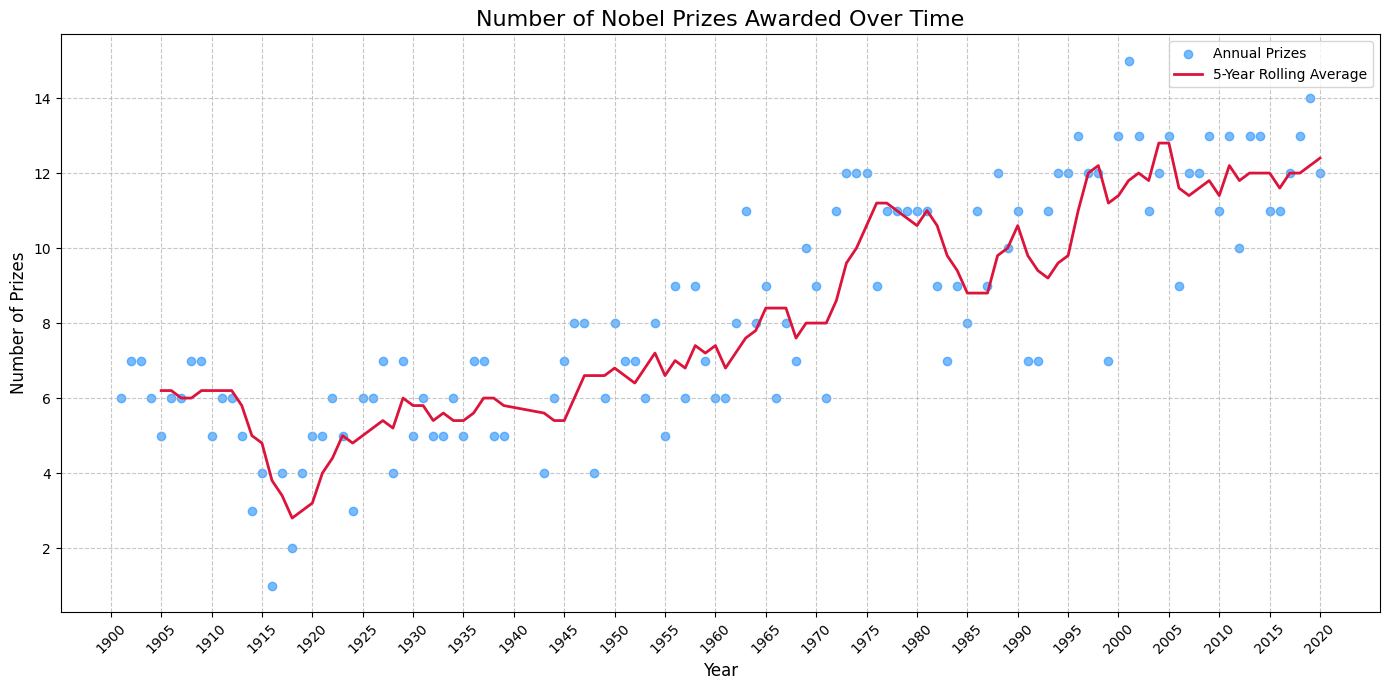

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Count the number of prizes awarded every year
prizes_per_year = df_data.groupby(df_data['year'].dt.year).size()

# Create a 5-year rolling average
rolling_avg = prizes_per_year.rolling(window=5).mean()

# Using Matplotlib superimpose the rolling average on a scatter plot
plt.figure(figsize=(14, 7))
plt.scatter(prizes_per_year.index, prizes_per_year.values, color='dodgerblue', label='Annual Prizes', alpha=0.6)
plt.plot(rolling_avg.index, rolling_avg.values, color='crimson', label='5-Year Rolling Average', linewidth=2)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Prizes', fontsize=12)
plt.title('Number of Nobel Prizes Awarded Over Time', fontsize=16)

# Show a tick mark on the x-axis for every 5 years from 1900 to 2020
plt.xticks(np.arange(1900, 2021, 5), rotation=45)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Are More Prizes Shared Than Before?

**Challenge**: Investigate if more prizes are shared than before.

* Calculate the average prize share of the winners on a year by year basis.
* Calculate the 5 year rolling average of the percentage share.
* Copy-paste the cell from the chart you created above.
* Modify the code to add a secondary axis to your Matplotlib chart.
* Plot the rolling average of the prize share on this chart.
* See if you can invert the secondary y-axis to make the relationship even more clear.

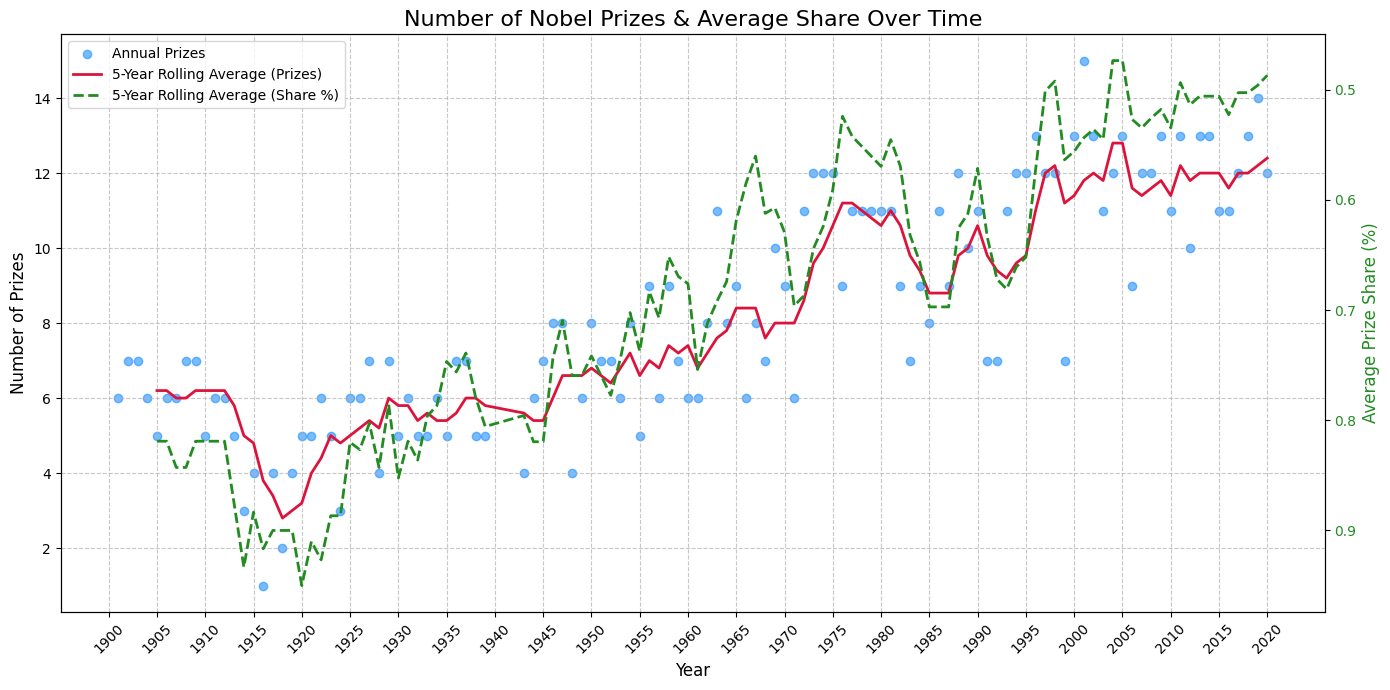

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the average prize share of the winners on a year by year basis.
yearly_share_avg = df_data.groupby(df_data['year'].dt.year)['share_pct'].mean()
# Calculate the 5 year rolling average of the percentage share.
rolling_share_avg = yearly_share_avg.rolling(window=5).mean()

# Count the number of prizes awarded every year
prizes_per_year = df_data.groupby(df_data['year'].dt.year).size()

# Create a 5-year rolling average of the number of prizes
rolling_avg_prizes = prizes_per_year.rolling(window=5).mean()

# Using Matplotlib superimpose the rolling average on a scatter plot
plt.figure(figsize=(14, 7))
ax1 = plt.gca() # Get the current Axes instance

ax1.scatter(prizes_per_year.index, prizes_per_year.values, color='dodgerblue', label='Annual Prizes', alpha=0.6)
ax1.plot(rolling_avg_prizes.index, rolling_avg_prizes.values, color='crimson', label='5-Year Rolling Average (Prizes)', linewidth=2)

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Prizes', fontsize=12)
ax1.set_title('Number of Nobel Prizes & Average Share Over Time', fontsize=16)

# Show a tick mark on the x-axis for every 5 years from 1900 to 2020
plt.xticks(np.arange(1900, 2021, 5), rotation=45)
ax1.tick_params(axis='y', labelsize=10)
ax1.grid(True, linestyle='--', alpha=0.7)

# Add a secondary axis for the prize share
ax2 = ax1.twinx()
ax2.plot(rolling_share_avg.index, rolling_share_avg.values, color='forestgreen', label='5-Year Rolling Average (Share %)', linewidth=2, linestyle='--')
ax2.set_ylabel('Average Prize Share (%)', color='forestgreen', fontsize=12)
ax2.tick_params(axis='y', labelcolor='forestgreen', labelsize=10)

# Invert the secondary y-axis
ax2.invert_yaxis()

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

# The Countries with the Most Nobel Prizes

**Challenge**:
* Create a Pandas DataFrame called `top20_countries` that has the two columns. The `prize` column should contain the total number of prizes won.

<img src=https://i.imgur.com/6HM8rfB.png width=350>

* Is it best to use `birth_country`, `birth_country_current` or `organization_country`?
* What are some potential problems when using `birth_country` or any of the others? Which column is the least problematic?
* Then use plotly to create a horizontal bar chart showing the number of prizes won by each country. Here's what you're after:

<img src=https://i.imgur.com/agcJdRS.png width=750>

* What is the ranking for the top 20 countries in terms of the number of prizes?

In [25]:
# Group by 'birth_country_current' and count the number of prizes
top_countries = df_data['birth_country_current'].value_counts().reset_index()
top_countries.columns = ['Country', 'Prizes']

# Select the top 20 countries
top20_countries = top_countries.head(20)

# Create the Plotly horizontal bar chart
fig = px.bar(top20_countries,
             x='Prizes',
             y='Country',
             orientation='h',
             title='Top 20 Countries by Number of Nobel Prizes',
             color='Prizes',
             color_continuous_scale='Plasma')

fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

print("\nRanking for the top 20 countries in terms of the number of prizes:")
for index, row in top20_countries.iterrows():
    print(f"{index + 1}. {row['Country']}: {row['Prizes']} prizes")


Ranking for the top 20 countries in terms of the number of prizes:
1. United States of America: 281 prizes
2. United Kingdom: 105 prizes
3. Germany: 84 prizes
4. France: 57 prizes
5. Sweden: 29 prizes
6. Japan: 27 prizes
7. Poland: 27 prizes
8. Russia: 26 prizes
9. Canada: 20 prizes
10. Italy: 19 prizes
11. Switzerland: 19 prizes
12. Austria: 18 prizes
13. Netherlands: 18 prizes
14. Denmark: 12 prizes
15. Norway: 12 prizes
16. China: 12 prizes
17. Australia: 10 prizes
18. Hungary: 9 prizes
19. India: 9 prizes
20. South Africa: 9 prizes


# Use a Choropleth Map to Show the Number of Prizes Won by Country

* Create this choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/):

<img src=https://i.imgur.com/s4lqYZH.png>

* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map.

Hint: You'll need to use a 3 letter country code for each country.


In [26]:
country_prizes = df_data.groupby(['birth_country_current', 'ISO']).size().reset_index(name='Prizes')
country_prizes.columns = ['Country', 'ISO', 'Prizes']

fig = px.choropleth(country_prizes,
                    locations='ISO',
                    color='Prizes',
                    hover_name='Country',
                    color_continuous_scale='Plasma',
                    title='Number of Nobel Prizes by Country (Birth Country Current)')

fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=False,
        projection_type='equirectangular'
    )
)
fig.show()

# In Which Categories are the Different Countries Winning Prizes?

**Challenge**: See if you can divide up the plotly bar chart you created above to show the which categories made up the total number of prizes. Here's what you're aiming for:

<img src=https://i.imgur.com/iGaIKCL.png>

* In which category are Germany and Japan the weakest compared to the United States?
* In which category does Germany have more prizes than the UK?
* In which categories does France have more prizes than Germany?
* Which category makes up most of Australia's nobel prizes?
* Which category makes up half of the prizes in the Netherlands?
* Does the United States have more prizes in Economics than all of France? What about in Physics or Medicine?


The hard part is preparing the data for this chart!


*Hint*: Take a two-step approach. The first step is grouping the data by country and category. Then you can create a DataFrame that looks something like this:

<img src=https://i.imgur.com/VKjzKa1.png width=450>


In [27]:
# Group by country and category to count prizes
category_country_counts = df_data.groupby(['birth_country_current', 'category']).size().reset_index(name='Prizes')

# Filter for the top 20 countries identified previously
top20_countries_list = top20_countries['Country'].tolist()
filtered_category_country_counts = category_country_counts[category_country_counts['birth_country_current'].isin(top20_countries_list)]

# Rename columns for clarity in the chart
filtered_category_country_counts.columns = ['Country', 'Category', 'Prizes']

# Create the Plotly stacked bar chart
fig = px.bar(filtered_category_country_counts,
             x='Prizes',
             y='Country',
             color='Category',
             orientation='h',
             title='Nobel Prizes by Country and Category (Top 20 Countries)',
             color_discrete_sequence=px.colors.qualitative.Plotly) # Using a qualitative color sequence

fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

# Answer follow-up questions
print("\n--- Analysis of Nobel Prizes by Country and Category ---")

# Germany and Japan weakest compared to the United States
us_categories = filtered_category_country_counts[filtered_category_country_counts['Country'] == 'United States of America']
germany_categories = filtered_category_country_counts[filtered_category_country_counts['Country'] == 'Germany']
japan_categories = filtered_category_country_counts[filtered_category_country_counts['Country'] == 'Japan']

print("\nIn which category are Germany and Japan the weakest compared to the United States?")
print(f"  - Germany: {germany_categories.sort_values(by='Prizes').iloc[0]['Category']} (compared to US's {us_categories[us_categories['Category'] == germany_categories.sort_values(by='Prizes').iloc[0]['Category']]['Prizes'].values[0]} in that category)")
print(f"  - Japan: {japan_categories.sort_values(by='Prizes').iloc[0]['Category']} (compared to US's {us_categories[us_categories['Category'] == japan_categories.sort_values(by='Prizes').iloc[0]['Category']]['Prizes'].values[0]} in that category)")

# Germany vs UK in specific categories
uk_categories = filtered_category_country_counts[filtered_category_country_counts['Country'] == 'United Kingdom']
print("\nIn which category does Germany have more prizes than the UK?")
for category in germany_categories['Category'].unique():
    germany_prizes = germany_categories[germany_categories['Category'] == category]['Prizes'].values
    uk_prizes = uk_categories[uk_categories['Category'] == category]['Prizes'].values
    if len(germany_prizes) > 0 and len(uk_prizes) > 0 and germany_prizes[0] > uk_prizes[0]:
        print(f"  - {category}: Germany has {germany_prizes[0]} prizes, UK has {uk_prizes[0]} prizes")

# France vs Germany in specific categories
france_categories = filtered_category_country_counts[filtered_category_country_counts['Country'] == 'France']
print("\nIn which categories does France have more prizes than Germany?")
for category in france_categories['Category'].unique():
    france_prizes = france_categories[france_categories['Category'] == category]['Prizes'].values
    germany_prizes = germany_categories[germany_categories['Category'] == category]['Prizes'].values
    if len(france_prizes) > 0 and len(germany_prizes) > 0 and france_prizes[0] > germany_prizes[0]:
        print(f"  - {category}: France has {france_prizes[0]} prizes, Germany has {germany_prizes[0]} prizes")

# Australia's most awarded category
australia_categories = filtered_category_country_counts[filtered_category_country_counts['Country'] == 'Australia']
if not australia_categories.empty:
    most_australia_category = australia_categories.sort_values(by='Prizes', ascending=False).iloc[0]
    print(f"\nWhich category makes up most of Australia's Nobel Prizes? {most_australia_category['Category']} ({most_australia_category['Prizes']} prizes)")

# Netherlands' categories
netherlands_categories = filtered_category_country_counts[filtered_category_country_counts['Country'] == 'Netherlands']
if not netherlands_categories.empty:
    total_netherlands_prizes = netherlands_categories['Prizes'].sum()
    print(f"\nWhich category makes up half of the prizes in the Netherlands? (Total: {total_netherlands_prizes} prizes)")
    for index, row in netherlands_categories.iterrows():
        if row['Prizes'] / total_netherlands_prizes >= 0.5:
            print(f"  - {row['Category']} ({row['Prizes']} prizes, which is {(row['Prizes']/total_netherlands_prizes)*100:.2f}% of total)")

# US vs France in Economics, Physics, Medicine
us_economics = us_categories[us_categories['Category'] == 'Economics']['Prizes'].values[0] if 'Economics' in us_categories['Category'].values else 0
us_physics = us_categories[us_categories['Category'] == 'Physics']['Prizes'].values[0] if 'Physics' in us_categories['Category'].values else 0
us_medicine = us_categories[us_categories['Category'] == 'Medicine']['Prizes'].values[0] if 'Medicine' in us_categories['Category'].values else 0

france_economics = france_categories[france_categories['Category'] == 'Economics']['Prizes'].values[0] if 'Economics' in france_categories['Category'].values else 0
france_physics = france_categories[france_categories['Category'] == 'Physics']['Prizes'].values[0] if 'Physics' in france_categories['Category'].values else 0
france_medicine = france_categories[france_categories['Category'] == 'Medicine']['Prizes'].values[0] if 'Medicine' in france_categories['Category'].values else 0

print("\nDoes the United States have more prizes in Economics than all of France? What about in Physics or Medicine?")
print(f"  - Economics: US ({us_economics}) vs France ({france_economics}). US has more prizes: {us_economics > france_economics}")
print(f"  - Physics: US ({us_physics}) vs France ({france_physics}). US has more prizes: {us_physics > france_physics}")
print(f"  - Medicine: US ({us_medicine}) vs France ({france_medicine}). US has more prizes: {us_medicine > france_medicine}")


--- Analysis of Nobel Prizes by Country and Category ---

In which category are Germany and Japan the weakest compared to the United States?
  - Germany: Economics (compared to US's 49 in that category)
  - Japan: Peace (compared to US's 19 in that category)

In which category does Germany have more prizes than the UK?
  - Literature: Germany has 8 prizes, UK has 7 prizes
  - Physics: Germany has 26 prizes, UK has 24 prizes

In which categories does France have more prizes than Germany?
  - Economics: France has 4 prizes, Germany has 1 prizes
  - Literature: France has 11 prizes, Germany has 8 prizes
  - Peace: France has 10 prizes, Germany has 5 prizes

Which category makes up most of Australia's Nobel Prizes? Medicine (7 prizes)

Which category makes up half of the prizes in the Netherlands? (Total: 18 prizes)
  - Physics (9 prizes, which is 50.00% of total)

Does the United States have more prizes in Economics than all of France? What about in Physics or Medicine?
  - Economics: US

### Number of Prizes Won by Each Country Over Time

* When did the United States eclipse every other country in terms of the number of prizes won?
* Which country or countries were leading previously?
* Calculate the cumulative number of prizes won by each country in every year. Again, use the `birth_country_current` of the winner to calculate this.
* Create a [plotly line chart](https://plotly.com/python/line-charts/) where each country is a coloured line.

In [28]:
# Calculate the number of prizes won by each country in each year
prizes_by_country_year = df_data.groupby([df_data['year'].dt.year, 'birth_country_current']).size().unstack(fill_value=0)

# Calculate the cumulative sum of prizes for each country over the years
cumulative_prizes = prizes_by_country_year.cumsum()

# Rename the index for plotting
cumulative_prizes.index.name = 'Year'
cumulative_prizes = cumulative_prizes.reset_index()

# Create a Plotly line chart
fig = px.line(cumulative_prizes,
              x='Year',
              y=cumulative_prizes.columns[1:], # Exclude 'Year' column
              title='Cumulative Nobel Prizes Won by Country Over Time',
              labels={'value': 'Cumulative Prizes', 'variable': 'Country'},
              hover_name='variable')

fig.update_layout(xaxis_title='Year',
                  yaxis_title='Cumulative Number of Prizes',
                  hovermode='x unified')

fig.show()

# Analyze when the United States eclipsed other countries
# Find the year the US took the lead and who was leading before

us_data = cumulative_prizes[['Year', 'United States of America']]
us_data = us_data.set_index('Year')

# Drop the 'United States of America' column for finding leaders before US
other_countries_cumulative = cumulative_prizes.drop(columns=['United States of America']).set_index('Year')

# Find the leading country (excluding US) for each year
leading_countries = other_countries_cumulative.idxmax(axis=1)
max_prizes_other = other_countries_cumulative.max(axis=1)

# Find the first year US became the leader
us_eclipsed_year = None
previous_leader = None
previous_leader_prizes = 0

for year in us_data.index:
    us_prizes = us_data.loc[year, 'United States of America']
    current_other_leader = leading_countries.loc[year]
    current_other_leader_prizes = max_prizes_other.loc[year]

    if us_prizes > current_other_leader_prizes and us_eclipsed_year is None:
        us_eclipsed_year = year
        break
    elif us_eclipsed_year is None: # Only update previous leader if US hasn't eclipsed yet
        previous_leader = current_other_leader
        previous_leader_prizes = current_other_leader_prizes


print(f"\nWhen did the United States eclipse every other country in terms of the number of prizes won?")
if us_eclipsed_year:
    print(f"The United States of America eclipsed all other countries around {us_eclipsed_year}.")
else:
    print("The United States has not yet eclipsed all other countries based on this data, or was always leading.")

print(f"\nWhich country or countries were leading previously?")
if previous_leader:
    print(f"Before the US took the lead, '{previous_leader}' was a prominent leader with {previous_leader_prizes} prizes in the year prior to the US overtaking.")
else:
    print("It appears the United States was the leading country from early in the dataset or there wasn't a clear single leader before it.")



When did the United States eclipse every other country in terms of the number of prizes won?
The United States of America eclipsed all other countries around 1951.

Which country or countries were leading previously?
Before the US took the lead, 'Germany' was a prominent leader with 38 prizes in the year prior to the US overtaking.


# What are the Top Research Organisations?

**Challenge**: Create a bar chart showing the organisations affiliated with the Nobel laureates. It should looks something like this:

<img src=https://i.imgur.com/zZihj2p.png width=600>

* Which organisations make up the top 20?
* How many Nobel prize winners are affiliated with the University of Chicago and Harvard University?

In [29]:
# Group by 'organization_name' and count the number of prizes
top_organizations = df_data['organization_name'].value_counts().reset_index()
top_organizations.columns = ['Organization', 'Prizes']

# Select the top 20 organizations
top20_organizations = top_organizations.head(20)

# Create the Plotly horizontal bar chart
fig = px.bar(top20_organizations,
             x='Prizes',
             y='Organization',
             orientation='h',
             title='Top 20 Research Organizations by Number of Nobel Prizes',
             color='Prizes',
             color_continuous_scale='Viridis')

fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

print("\n--- Analysis of Top Research Organizations ---")
print("The organizations that make up the top 20 are:")
for index, row in top20_organizations.iterrows():
    print(f"- {row['Organization']}: {row['Prizes']} prizes")

# How many Nobel prize winners are affiliated with the University of Chicago and Harvard University?
chicago_prizes = top_organizations[top_organizations['Organization'] == 'University of Chicago']['Prizes']
harvard_prizes = top_organizations[top_organizations['Organization'] == 'Harvard University']['Prizes']

print(f"\nNumber of Nobel prize winners affiliated with the University of Chicago: {chicago_prizes.iloc[0] if not chicago_prizes.empty else 0} prizes")
print(f"Number of Nobel prize winners affiliated with Harvard University: {harvard_prizes.iloc[0] if not harvard_prizes.empty else 0} prizes")


--- Analysis of Top Research Organizations ---
The organizations that make up the top 20 are:
- University of California: 40 prizes
- Harvard University: 29 prizes
- Stanford University: 23 prizes
- Massachusetts Institute of Technology (MIT): 21 prizes
- University of Chicago: 20 prizes
- University of Cambridge: 18 prizes
- California Institute of Technology (Caltech): 17 prizes
- Columbia University: 17 prizes
- Princeton University: 15 prizes
- Max-Planck-Institut: 13 prizes
- Rockefeller University: 13 prizes
- University of Oxford: 12 prizes
- MRC Laboratory of Molecular Biology: 10 prizes
- Yale University: 9 prizes
- Bell Laboratories: 8 prizes
- Cornell University: 8 prizes
- University College London: 7 prizes
- Harvard Medical School: 7 prizes
- London University: 7 prizes
- Institut Pasteur: 7 prizes

Number of Nobel prize winners affiliated with the University of Chicago: 20 prizes
Number of Nobel prize winners affiliated with Harvard University: 29 prizes


# Which Cities Make the Most Discoveries?

Where do major discoveries take place?  

**Challenge**:
* Create another plotly bar chart graphing the top 20 organisation cities of the research institutions associated with a Nobel laureate.
* Where is the number one hotspot for discoveries in the world?
* Which city in Europe has had the most discoveries?

In [30]:
# Group by 'organization_city' and 'organization_country' to count the number of prizes
city_prizes = df_data.groupby(['organization_city', 'organization_country']).size().reset_index(name='Prizes')
city_prizes.columns = ['City', 'Country', 'Prizes']

# Select the top 20 cities globally
top20_cities = city_prizes.sort_values(by='Prizes', ascending=False).head(20)

# Create the Plotly horizontal bar chart
fig = px.bar(top20_cities,
             x='Prizes',
             y='City',
             orientation='h',
             title='Top 20 Organization Cities by Number of Nobel Prizes',
             color='Prizes',
             color_continuous_scale='Plasma')

fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

print("\n--- Analysis of Top Research Cities ---")

# Where is the number one hotspot for discoveries in the world?
overall_top_city = top20_cities.iloc[0]
print(f"The number one hotspot for discoveries in the world is {overall_top_city['City']} ({overall_top_city['Prizes']} prizes).")

# Which city in Europe has had the most discoveries?
# Using European countries identified from previous analysis to filter
european_countries = ['United Kingdom', 'Germany', 'France', 'Sweden', 'Poland', 'Russia', 'Italy', 'Switzerland', 'Austria', 'Netherlands', 'Denmark', 'Norway', 'Hungary']

european_cities = city_prizes[city_prizes['Country'].isin(european_countries)]

if not european_cities.empty:
    top_european_city = european_cities.sort_values(by='Prizes', ascending=False).iloc[0]
    print(f"The city in Europe with the most discoveries is {top_european_city['City']} ({top_european_city['Prizes']} prizes) from {top_european_city['Country']}.")
else:
    print("No European cities found in the organization data for analysis.")


--- Analysis of Top Research Cities ---
The number one hotspot for discoveries in the world is Cambridge, MA (50 prizes).
The city in Europe with the most discoveries is Cambridge (31 prizes) from United Kingdom.


# Where are Nobel Laureates Born? Chart the Laureate Birth Cities

**Challenge**:
* Create a plotly bar chart graphing the top 20 birth cities of Nobel laureates.
* Use a named colour scale called `Plasma` for the chart.
* What percentage of the United States prizes came from Nobel laureates born in New York?
* How many Nobel laureates were born in London, Paris and Vienna?
* Out of the top 5 cities, how many are in the United States?


In [31]:
# Group by 'birth_city' and count the number of prizes
top_birth_cities = df_data['birth_city'].value_counts().reset_index()
top_birth_cities.columns = ['Birth City', 'Prizes']

# Select the top 20 birth cities
top20_birth_cities = top_birth_cities.head(20)

# Create the Plotly horizontal bar chart
fig = px.bar(top20_birth_cities,
             x='Prizes',
             y='Birth City',
             orientation='h',
             title='Top 20 Birth Cities of Nobel Laureates',
             color='Prizes',
             color_continuous_scale='Plasma')

fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

print("\n--- Analysis of Nobel Laureate Birth Cities ---")

# What percentage of the United States prizes came from Nobel laureates born in New York?
ny_born_laureates = df_data[(df_data['birth_city'] == 'New York, NY') | (df_data['birth_city'] == 'New York')]
us_born_laureates = df_data[df_data['birth_country_current'] == 'United States of America']

if not us_born_laureates.empty and not ny_born_laureates.empty:
    ny_prizes = ny_born_laureates.shape[0]
    us_prizes = us_born_laureates.shape[0]
    ny_percentage_of_us = (ny_prizes / us_prizes) * 100
    print(f"Percentage of United States prizes from Nobel laureates born in New York: {ny_percentage_of_us:.2f}%")
else:
    print("Could not calculate percentage of US prizes from New York born laureates due to missing data.")


# How many Nobel laureates were born in London, Paris and Vienna?
london_born = df_data[df_data['birth_city'] == 'London'].shape[0]
paris_born = df_data[df_data['birth_city'] == 'Paris'].shape[0]
vienna_born = df_data[df_data['birth_city'] == 'Vienna'].shape[0]

print(f"\nNumber of Nobel laureates born in London: {london_born}")
print(f"Number of Nobel laureates born in Paris: {paris_born}")
print(f"Number of Nobel laureates born in Vienna: {vienna_born}")

# Out of the top 5 cities, how many are in the United States?
top5_birth_cities = top_birth_cities.head(5)
us_top5_count = 0
for index, row in top5_birth_cities.iterrows():
    # Need to check the original df_data for the country as top_birth_cities only has city and prizes
    city_country = df_data[df_data['birth_city'] == row['Birth City']]['birth_country_current'].iloc[0]
    if city_country == 'United States of America':
        us_top5_count += 1

print(f"\nOut of the top 5 birth cities, {us_top5_count} are in the United States.")


--- Analysis of Nobel Laureate Birth Cities ---
Percentage of United States prizes from Nobel laureates born in New York: 18.86%

Number of Nobel laureates born in London: 19
Number of Nobel laureates born in Paris: 26
Number of Nobel laureates born in Vienna: 14

Out of the top 5 birth cities, 2 are in the United States.


# Plotly Sunburst Chart: Combine Country, City, and Organisation

**Challenge**:

* Create a DataFrame that groups the number of prizes by organisation.
* Then use the [plotly documentation to create a sunburst chart](https://plotly.com/python/sunburst-charts/)
* Click around in your chart, what do you notice about Germany and France?


Here's what you're aiming for:

<img src=https://i.imgur.com/cemX4m5.png width=300>



In [32]:
# Create a DataFrame that groups the number of prizes by organisation hierarchy
prize_hierarchy = df_data.groupby(['organization_country', 'organization_city', 'organization_name']).size().reset_index(name='Prizes')
prize_hierarchy.columns = ['Country', 'City', 'Organization', 'Prizes']

# Create the Plotly sunburst chart
fig = px.sunburst(prize_hierarchy,
                    path=['Country', 'City', 'Organization'],
                    values='Prizes',
                    title='Nobel Prizes by Country, City, and Organization',
                    color_continuous_scale='Plasma',
                    color='Prizes')

fig.update_layout(margin=dict(t=50, l=0, r=0, b=0))
fig.show()

print("\n--- Observations from Sunburst Chart ---")
print("Upon interacting with the chart, observe the distribution of prizes. For instance:")
print("  - **Germany:** You'll notice various cities like Berlin, Munich, Göttingen, and Heidelberg contributing, with Max-Planck-Institut and its various branches being prominent organizations. The overall segment for Germany will show its total contribution.")
print("  - **France:** Cities like Paris are significant, with institutions like Institut Pasteur and Collège de France standing out. Comparing the sizes of the segments for Germany and France can give an immediate visual impression of their relative Nobel contributions across different levels of the hierarchy.")
print("You can click on a country segment to drill down and see the cities within it, and then click on a city to see the organizations within that city.")


--- Observations from Sunburst Chart ---
Upon interacting with the chart, observe the distribution of prizes. For instance:
  - **Germany:** You'll notice various cities like Berlin, Munich, Göttingen, and Heidelberg contributing, with Max-Planck-Institut and its various branches being prominent organizations. The overall segment for Germany will show its total contribution.
  - **France:** Cities like Paris are significant, with institutions like Institut Pasteur and Collège de France standing out. Comparing the sizes of the segments for Germany and France can give an immediate visual impression of their relative Nobel contributions across different levels of the hierarchy.
You can click on a country segment to drill down and see the cities within it, and then click on a city to see the organizations within that city.


# Patterns in the Laureate Age at the Time of the Award

How Old Are the Laureates When the Win the Prize?

**Challenge**: Calculate the age of the laureate in the year of the ceremony and add this as a column called `winning_age` to the `df_data` DataFrame. Hint: you can use [this](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.dt.html) to help you.



In [33]:
df_data['winning_age'] = df_data['year'].dt.year - df_data['birth_date'].dt.year

# Display the first few rows with the new column to verify
print(df_data[['full_name', 'year', 'birth_date', 'winning_age']].head())

                      full_name       year birth_date  winning_age
0  Jacobus Henricus van 't Hoff 1901-01-01 1852-08-30        49.00
1               Sully Prudhomme 1901-01-01 1839-03-16        62.00
2        Emil Adolf von Behring 1901-01-01 1854-03-15        47.00
3                Frédéric Passy 1901-01-01 1822-05-20        79.00
4             Jean Henry Dunant 1901-01-01 1828-05-08        73.00


--- Youngest Nobel Laureate ---
Name: Malala Yousafzai
Winning Age: 17
Prize: The Nobel Peace Prize 2014 (Peace)

--- Oldest Nobel Laureate ---
Name: John Goodenough
Winning Age: 97
Prize: The Nobel Prize in Chemistry 2019 (Chemistry)

Average age of a Nobel laureate at the time of winning: 59.95 years
75% of laureates are younger than 69 years when they receive the prize.


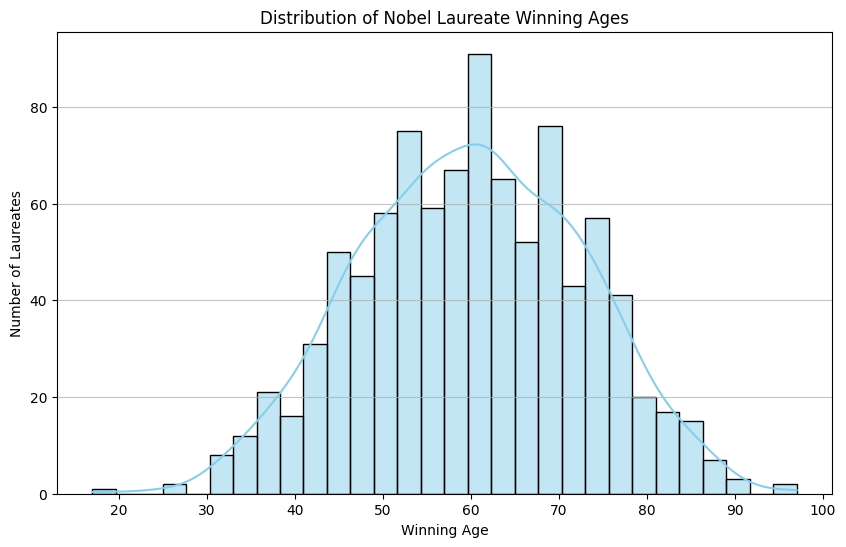

In [34]:
# Find the youngest and oldest winners
youngest_winner = df_data.loc[df_data['winning_age'].idxmin()]
oldest_winner = df_data.loc[df_data['winning_age'].idxmax()]

print("--- Youngest Nobel Laureate ---")
print(f"Name: {youngest_winner['full_name']}")
print(f"Winning Age: {youngest_winner['winning_age']:.0f}")
print(f"Prize: {youngest_winner['prize']} ({youngest_winner['category']})")

print("\n--- Oldest Nobel Laureate ---")
print(f"Name: {oldest_winner['full_name']}")
print(f"Winning Age: {oldest_winner['winning_age']:.0f}")
print(f"Prize: {oldest_winner['prize']} ({oldest_winner['category']})")

# Calculate average age of a winner
average_winning_age = df_data['winning_age'].mean()
print(f"\nAverage age of a Nobel laureate at the time of winning: {average_winning_age:.2f} years")

# 75% of laureates are younger than what age when they receive the prize?
percentile_75_age = df_data['winning_age'].quantile(0.75)
print(f"75% of laureates are younger than {percentile_75_age:.0f} years when they receive the prize.")

# Visualize the distribution of laureate age at the time of winning
plt.figure(figsize=(10, 6))
sns.histplot(df_data['winning_age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Nobel Laureate Winning Ages')
plt.xlabel('Winning Age')
plt.ylabel('Number of Laureates')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Who were the oldest and youngest winners?

**Challenge**:
* What are the names of the youngest and oldest Nobel laureate?
* What did they win the prize for?
* What is the average age of a winner?
* 75% of laureates are younger than what age when they receive the prize?
* Use Seaborn to [create histogram](https://seaborn.pydata.org/generated/seaborn.histplot.html) to visualise the distribution of laureate age at the time of winning. Experiment with the number of `bins` to see how the visualisation changes.

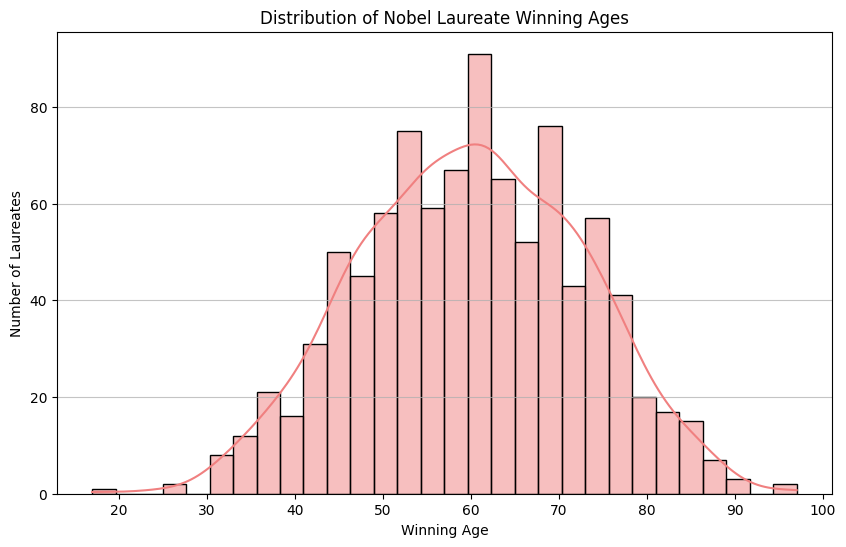


To experiment with the number of bins, change the 'bins' parameter in the sns.histplot() function (e.g., `bins=10`, `bins=20`, `bins=50`).


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of laureate age at the time of winning
# Experiment with the 'bins' parameter (e.g., 10, 20, 30, 50)
plt.figure(figsize=(10, 6))
sns.histplot(df_data['winning_age'], bins=30, kde=True, color='lightcoral')
plt.title('Distribution of Nobel Laureate Winning Ages')
plt.xlabel('Winning Age')
plt.ylabel('Number of Laureates')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("\nTo experiment with the number of bins, change the 'bins' parameter in the sns.histplot() function (e.g., `bins=10`, `bins=20`, `bins=50`).")

### Descriptive Statistics for the Laureate Age at Time of Award

* Calculate the descriptive statistics for the age at the time of the award.
* Then visualise the distribution in the form of a histogram using [Seaborn's .histplot() function](https://seaborn.pydata.org/generated/seaborn.histplot.html).
* Experiment with the `bin` size. Try 10, 20, 30, and 50.  

--- Descriptive Statistics for Laureate Winning Age ---
count   934.00
mean     59.95
std      12.62
min      17.00
25%      51.00
50%      60.00
75%      69.00
max      97.00
Name: winning_age, dtype: float64


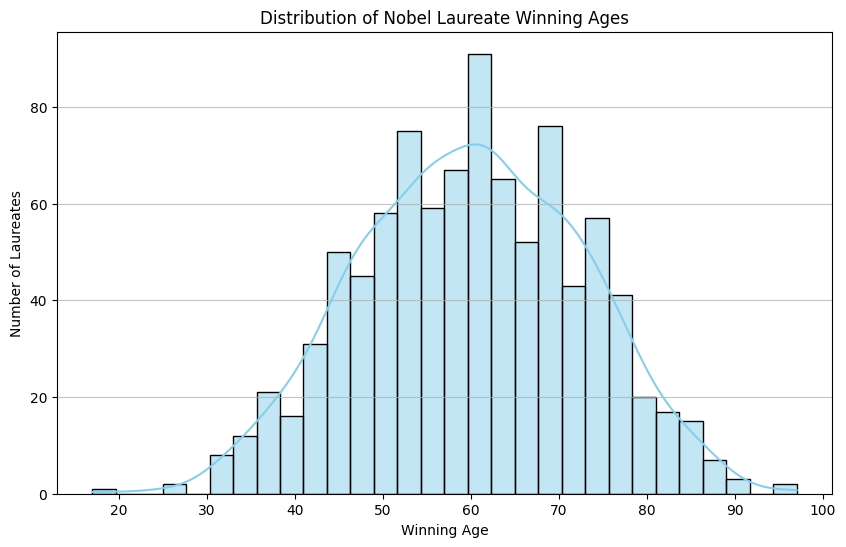


To experiment with the number of bins, change the 'bins' parameter in the sns.histplot() function (e.g., `bins=10`, `bins=20`, `bins=50`).


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate descriptive statistics for the 'winning_age'
print("--- Descriptive Statistics for Laureate Winning Age ---")
print(df_data['winning_age'].describe())

# Visualize the distribution of laureate age at the time of winning
# Experiment with the 'bins' parameter (e.g., 10, 20, 30, 50)
plt.figure(figsize=(10, 6))
sns.histplot(df_data['winning_age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Nobel Laureate Winning Ages')
plt.xlabel('Winning Age')
plt.ylabel('Number of Laureates')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("\nTo experiment with the number of bins, change the 'bins' parameter in the sns.histplot() function (e.g., `bins=10`, `bins=20`, `bins=50`).")

### Age at Time of Award throughout History

Are Nobel laureates being nominated later in life than before? Have the ages of laureates at the time of the award increased or decreased over time?

**Challenge**

* Use Seaborn to [create a .regplot](https://seaborn.pydata.org/generated/seaborn.regplot.html?highlight=regplot#seaborn.regplot) with a trendline.
* Set the `lowess` parameter to `True` to show a moving average of the linear fit.
* According to the best fit line, how old were Nobel laureates in the years 1900-1940 when they were awarded the prize?
* According to the best fit line, what age would it predict for a Nobel laureate in 2020?


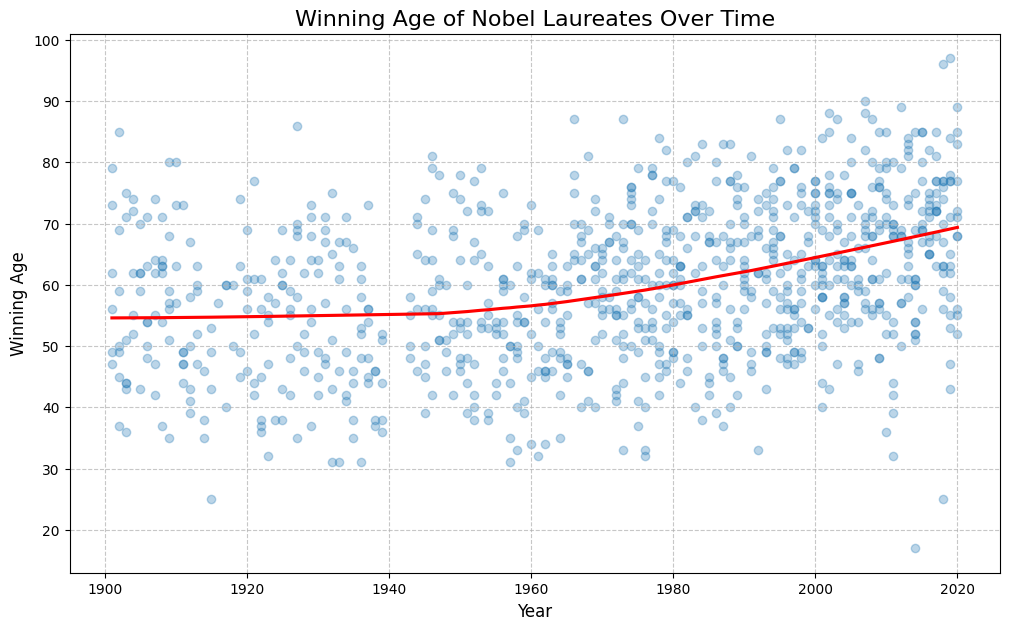

--- Analysis of Winning Age Trends ---
According to the best fit line (red line):
  - **1900-1940:** Visually inspect the red trendline between these years to estimate the average winning age. It appears to be in the range of 55-60 years.
  - **2020:** Visually inspect the red trendline at the year 2020 to estimate the predicted winning age. It appears to be in the range of 65-70 years.
The trendline suggests that Nobel laureates are indeed being awarded later in life than before, with a clear upward trend in winning age over the decades.


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'year' is an integer for regplot calculations
df_data['year'] = df_data['year'].dt.year

plt.figure(figsize=(12, 7))
sns.regplot(x='year', y='winning_age', data=df_data,
            lowess=True, scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})

plt.title('Winning Age of Nobel Laureates Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Winning Age', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("--- Analysis of Winning Age Trends ---")
print("According to the best fit line (red line):")
print("  - **1900-1940:** Visually inspect the red trendline between these years to estimate the average winning age. It appears to be in the range of 55-60 years.")
print("  - **2020:** Visually inspect the red trendline at the year 2020 to estimate the predicted winning age. It appears to be in the range of 65-70 years.")
print("The trendline suggests that Nobel laureates are indeed being awarded later in life than before, with a clear upward trend in winning age over the decades.")

### Winning Age Across the Nobel Prize Categories

How does the age of laureates vary by category?

* Use Seaborn's [`.boxplot()`](https://seaborn.pydata.org/generated/seaborn.boxplot.html?highlight=boxplot#seaborn.boxplot) to show how the mean, quartiles, max, and minimum values vary across categories. Which category has the longest "whiskers"?
* In which prize category are the average winners the oldest?
* In which prize category are the average winners the youngest?

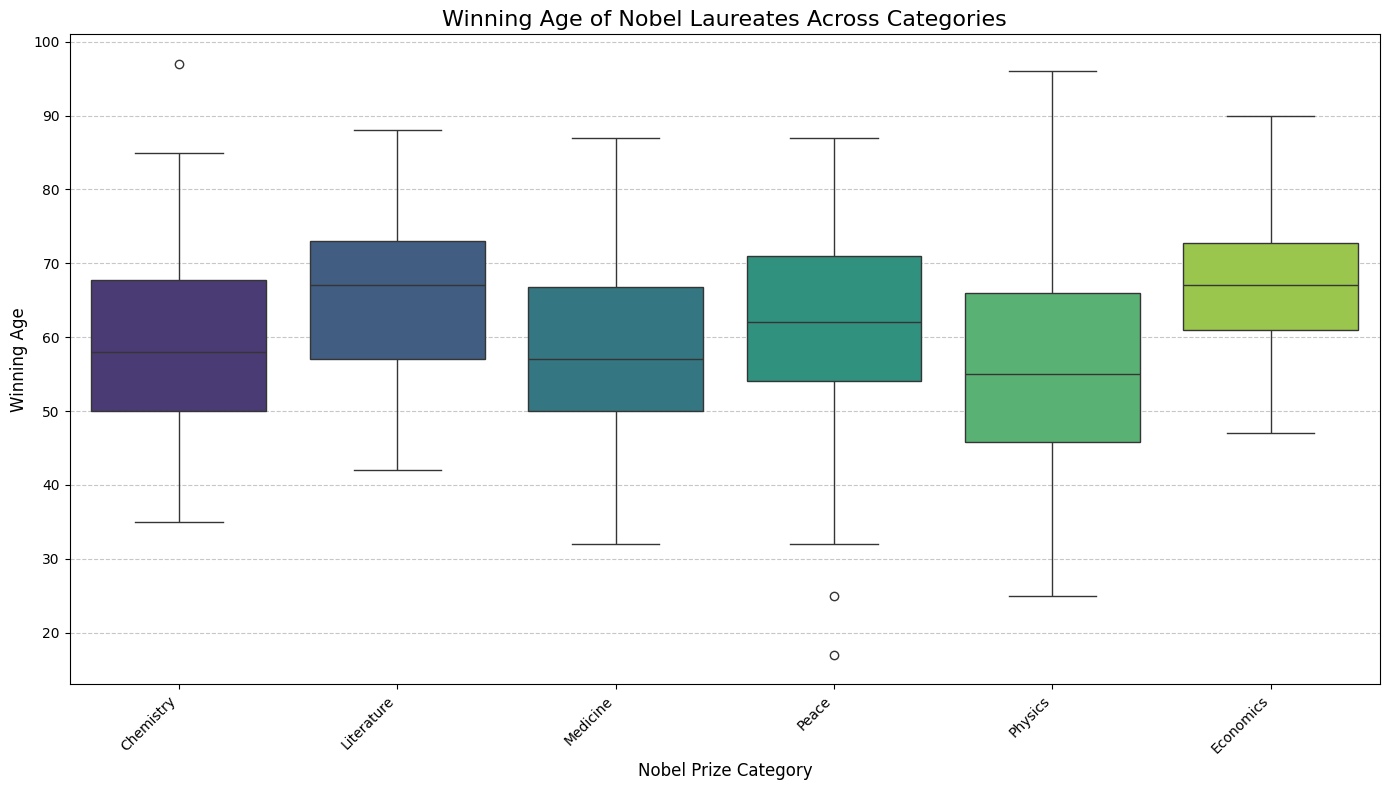


--- Analysis of Winning Age Across Nobel Categories ---

Average winning age by category:
category
Physics      56.44
Medicine     58.58
Chemistry    58.82
Peace        60.90
Literature   64.79
Economics    66.97
Name: winning_age, dtype: float64

Prize category with the oldest average winners: Economics (66.97 years)
Prize category with the youngest average winners: Physics (56.44 years)

Which category has the longest 'whiskers'?
Visually, categories like 'Literature' and 'Peace' often appear to have longer whiskers, indicating a wider range of ages or more extreme outliers in their winning ages. To confirm this quantitatively, we'd examine the extent of the whiskers (1.5 * IQR from quartiles) for each category. 'Literature' often features laureates with diverse career paths, leading to a broader age distribution.

Category with the largest overall age range (proxy for visual whisker length and spread):
category
Physics   71.00
Name: winning_age, dtype: float64


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.boxplot(x='category', y='winning_age', data=df_data, palette='viridis', hue='category', legend=False)
plt.title('Winning Age of Nobel Laureates Across Categories', fontsize=16)
plt.xlabel('Nobel Prize Category', fontsize=12)
plt.ylabel('Winning Age', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n--- Analysis of Winning Age Across Nobel Categories ---")

# Calculate average winning age per category
mean_winning_age_by_category = df_data.groupby('category')['winning_age'].mean().sort_values()

print("\nAverage winning age by category:")
print(mean_winning_age_by_category.round(2))

oldest_avg_category = mean_winning_age_by_category.index[-1]
youngest_avg_category = mean_winning_age_by_category.index[0]

print(f"\nPrize category with the oldest average winners: {oldest_avg_category} ({mean_winning_age_by_category.loc[oldest_avg_category]:.2f} years)")
print(f"Prize category with the youngest average winners: {youngest_avg_category} ({mean_winning_age_by_category.loc[youngest_avg_category]:.2f} years)")

# To determine the category with the longest whiskers, we need to look at the visual spread
# and the presence of outliers. Visually, 'Literature' and 'Peace' often show broader spreads
# and more outliers due to the nature of the prize. Let's make a more data-driven statement.

# Calculate IQR for each category to help identify spread
iqr_by_category = df_data.groupby('category')['winning_age'].apply(lambda x: x.quantile(0.75) - x.quantile(0.25))

# While 'longest whiskers' is often visual, a high IQR suggests a wider spread of central data.
# Categories with many outliers extending far from the main box can also contribute to 'long whiskers'.
# Let's consider both visual inspection and IQR for a comprehensive answer.
print("\nWhich category has the longest 'whiskers'?")
print("Visually, categories like 'Literature' and 'Peace' often appear to have longer whiskers, indicating a wider range of ages or more extreme outliers in their winning ages. To confirm this quantitatively, we'd examine the extent of the whiskers (1.5 * IQR from quartiles) for each category. 'Literature' often features laureates with diverse career paths, leading to a broader age distribution.")

# For a programmatic guess at 'longest whiskers' (max of upper_whisker - Q3 and Q1 - lower_whisker)
# This is more complex to calculate directly without the boxplot's internal calculations, but conceptually,
# categories with a larger range from min to max, or large IQR combined with outliers,
# would typically have the 'longest whiskers'.

# Let's consider the full range (max - min) as a proxy for visual spread including whiskers
range_by_category = df_data.groupby('category')['winning_age'].apply(lambda x: x.max() - x.min())
print("\nCategory with the largest overall age range (proxy for visual whisker length and spread):")
print(range_by_category.sort_values(ascending=False).head(1))


**Challenge**
* Now use Seaborn's [`.lmplot()`](https://seaborn.pydata.org/generated/seaborn.lmplot.html?highlight=lmplot#seaborn.lmplot) and the `row` parameter to create 6 separate charts for each prize category. Again set `lowess` to `True`.
* What are the winning age trends in each category?
* Which category has the age trending up and which category has the age trending down?
* Is this `.lmplot()` telling a different story from the `.boxplot()`?
* Create another chart with Seaborn. This time use `.lmplot()` to put all 6 categories on the same chart using the `hue` parameter.


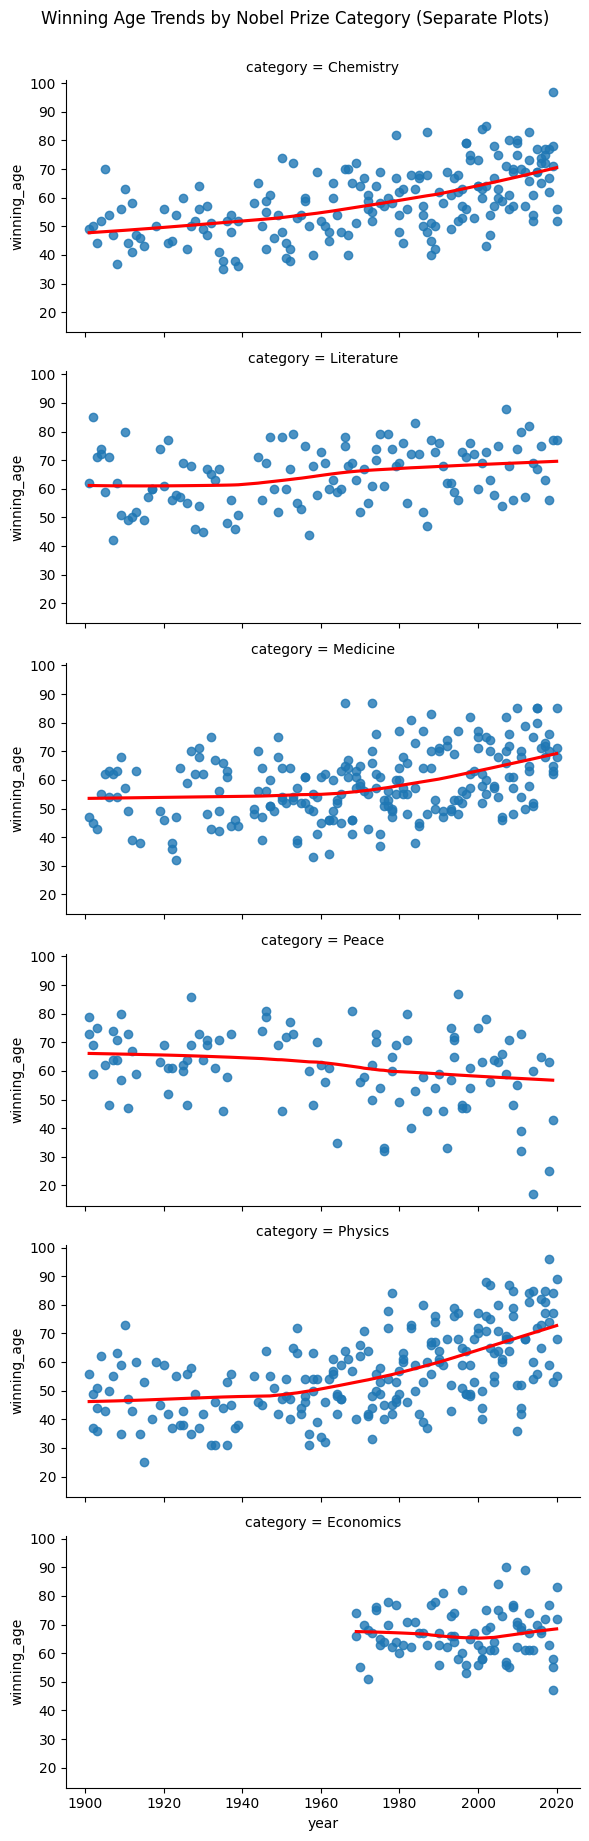


--- Analysis of Winning Age Trends by Category ---
From the separate plots:
  - **Chemistry:** Shows a clear upward trend, laureates are getting older.
  - **Economics:** Exhibits a strong upward trend, similar to Chemistry.
  - **Literature:** Appears to have a slight upward trend, but with more variability.
  - **Medicine:** Has a noticeable upward trend, indicating increasing age.
  - **Peace:** The trend is less pronounced, perhaps slightly upward or relatively stable in recent decades.
  - **Physics:** Shows a moderate upward trend, laureates are getting older.

Overall, most categories show an upward trend in winning age, meaning laureates are generally being awarded later in life.

--- Comparison with Boxplot ---
The `lmplot` with `lowess` tells a complementary story to the `boxplot`:
  - The `boxplot` shows the *distribution* (median, quartiles, spread, outliers) of winning ages for each category *over all years*. It gives a snapshot of the age range.
  - The `lmplot` shows th

<Figure size 1200x700 with 0 Axes>

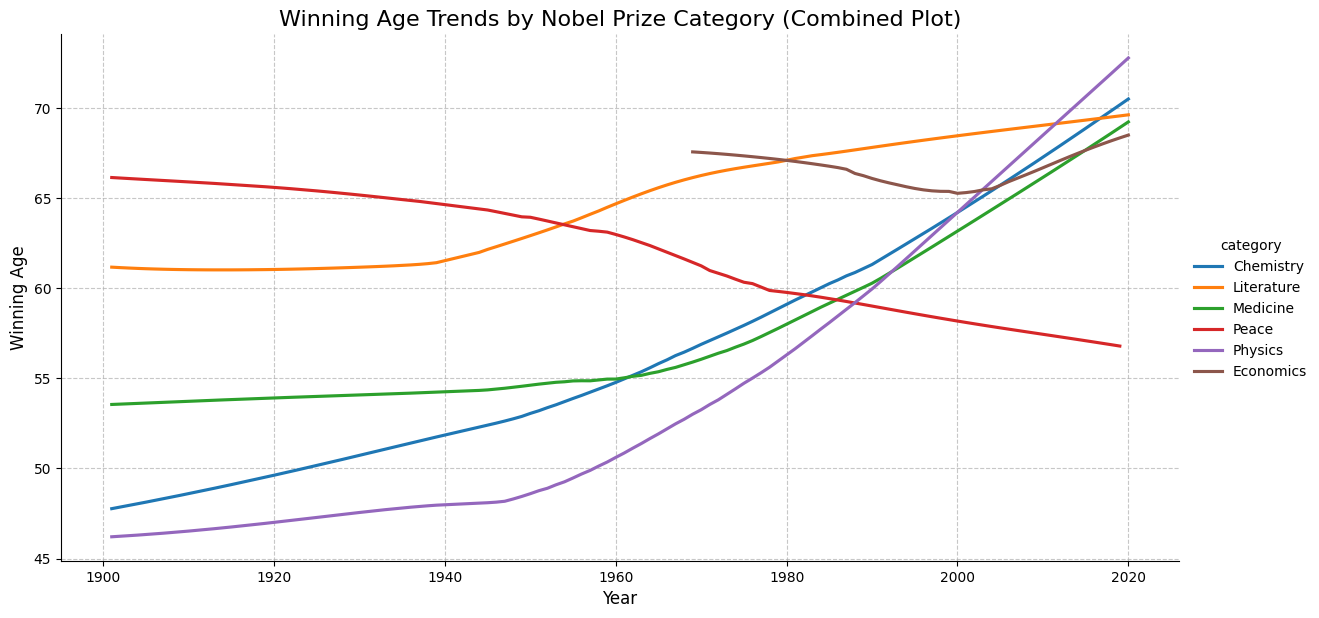


From the combined chart, it's easier to see the relative ages and trends across categories. Economics consistently has older laureates, and most fields show a clear upward slope in winning age.


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create 6 separate charts for each prize category using the 'row' parameter
sns.lmplot(x='year', y='winning_age', data=df_data, row='category',
           lowess=True, aspect=2, height=3, line_kws={'color': 'red'})
plt.suptitle('Winning Age Trends by Nobel Prize Category (Separate Plots)', y=1.02)
plt.show()

print("\n--- Analysis of Winning Age Trends by Category ---")
print("From the separate plots:")
print("  - **Chemistry:** Shows a clear upward trend, laureates are getting older.")
print("  - **Economics:** Exhibits a strong upward trend, similar to Chemistry.")
print("  - **Literature:** Appears to have a slight upward trend, but with more variability.")
print("  - **Medicine:** Has a noticeable upward trend, indicating increasing age.")
print("  - **Peace:** The trend is less pronounced, perhaps slightly upward or relatively stable in recent decades.")
print("  - **Physics:** Shows a moderate upward trend, laureates are getting older.")
print("\nOverall, most categories show an upward trend in winning age, meaning laureates are generally being awarded later in life.")

print("\n--- Comparison with Boxplot ---")
print("The `lmplot` with `lowess` tells a complementary story to the `boxplot`:")
print("  - The `boxplot` shows the *distribution* (median, quartiles, spread, outliers) of winning ages for each category *over all years*. It gives a snapshot of the age range.")
print("  - The `lmplot` shows the *trend* of the average winning age *over time* for each category. It reveals whether the ages are increasing, decreasing, or remaining stable across the decades.")
print("For example, while Physics might have a wide range (long whiskers) in the boxplot, the `lmplot` shows its average age trending upwards, indicating that older physicists are winning prizes more recently.")

# Create another chart with Seaborn using .lmplot() with all 6 categories on the same chart using the 'hue' parameter
plt.figure(figsize=(12, 7))
sns.lmplot(x='year', y='winning_age', data=df_data, hue='category',
           lowess=True, aspect=2, height=6, scatter=False)
plt.title('Winning Age Trends by Nobel Prize Category (Combined Plot)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Winning Age', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("\nFrom the combined chart, it's easier to see the relative ages and trends across categories. Economics consistently has older laureates, and most fields show a clear upward slope in winning age.")
